# Long-Time Entanglement and Variance

This notebook computes the long-time relationship between entanglement entropy and the variance of the raw accumulated-time Trotter simulation error.

Default long-time settings are `delta_t = 0.1` and `steps = 100`, so the total evolution time is `t = 10`.

## Imports and Parameters

In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "reproduce" / "src").exists():
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Could not locate repository root")
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from reproduce.src.resources import part_entropy
from reproduce.src.simulation_backend import NearestNeighbour1D, expH, pf
from reproduce.src.variance_experiment import evolved_states, sample_trotter_errors


In [ ]:
N = 10
STATE_DEPTH = 40
SUBSYSTEM_SIZE = 4
SAMPLES = 2000

DELTA_T = 0.1
STEPS = 100
TOTAL_TIME = DELTA_T * STEPS
TROTTER_ORDER = 2

TYPICAL_SEED = 1234
ATYPICAL_SEED = 5678

OUTPUT_ROOT = REPO_ROOT / "reproduce" / "outputs" / "long_time_ent_variance"
TYPICAL_DIR = OUTPUT_ROOT / "typical"
ATYPICAL_DIR = OUTPUT_ROOT / "atypical"
FIGURE_DIR = OUTPUT_ROOT / "figures"
for directory in (TYPICAL_DIR, ATYPICAL_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

OUTPUT_ROOT


## Build Input States

The typical and atypical input-state families follow the same mixed-field Ising settings used by the variance workflow. The long-time error operator is built separately below.

In [ ]:
def build_state_family(case):
    hx = 0.8090 if case == "typical" else 0.0
    model = NearestNeighbour1D(n=N, Jx=1.0, hx=hx, hy=0.9045, pbc=True)
    states = evolved_states(model, N, STATE_DEPTH)
    entropies = part_entropy(states, SUBSYSTEM_SIZE)
    return states, entropies


typical_states, typical_entropies = build_state_family("typical")
atypical_states, atypical_entropies = build_state_family("atypical")

np.save(TYPICAL_DIR / "states.npy", np.asarray([state.data for state in typical_states]))
np.save(TYPICAL_DIR / "entropies.npy", typical_entropies)
np.save(ATYPICAL_DIR / "states.npy", np.asarray([state.data for state in atypical_states]))
np.save(ATYPICAL_DIR / "entropies.npy", atypical_entropies)


## Build Long-Time Error Operator

This uses a Heisenberg-type nearest-neighbour Hamiltonian, total time `t = 10`, and `steps = 100`. The product formula call uses the parameter `TROTTER_ORDER` directly.

In [ ]:
long_time_model = NearestNeighbour1D(
    n=N,
    Jx=1.0,
    Jy=1.0,
    Jz=1.0,
    hx=0.2,
    hy=0.0,
    hz=0.0,
    pbc=True,
)

exact_u = expH(long_time_model.ham, TOTAL_TIME)
trotter_u = pf(
    h_list=long_time_model.ham_par,
    t=TOTAL_TIME,
    r=STEPS,
    order=TROTTER_ORDER,
)
error_u = exact_u - trotter_u


## Sample Errors and Compute Variance

For each input state, this samples local random Clifford frames, computes the raw accumulated-time simulation error, and takes the variance of those raw error samples.

In [ ]:
def sample_variance_series(states, seed, output_dir, prefix):
    rng = np.random.default_rng(seed)
    variances = np.empty(len(states), dtype=float)
    for index, state in enumerate(states):
        errors = sample_trotter_errors(
            state=state,
            error_matrix=error_u,
            n=N,
            samples=SAMPLES,
            rng=rng,
        )
        np.save(output_dir / f"{prefix}_{index}.npy", errors)
        variances[index] = np.var(errors)
    np.save(output_dir / "variances.npy", variances)
    return variances


typical_variances = sample_variance_series(typical_states, TYPICAL_SEED, TYPICAL_DIR, "ent")
atypical_variances = sample_variance_series(atypical_states, ATYPICAL_SEED, ATYPICAL_DIR, "antient")


## Save Metadata

In [ ]:
metadata = {
    "n": N,
    "state_depth": STATE_DEPTH,
    "subsystem_size": SUBSYSTEM_SIZE,
    "samples": SAMPLES,
    "delta_t": DELTA_T,
    "steps": STEPS,
    "total_time": TOTAL_TIME,
    "trotter_order": TROTTER_ORDER,
    "typical_seed": TYPICAL_SEED,
    "atypical_seed": ATYPICAL_SEED,
    "error_rescaling": "none",
    "variance_definition": "np.var(raw accumulated-time error samples)",
}

with (OUTPUT_ROOT / "metadata.txt").open("w", encoding="utf-8") as handle:
    for key, value in metadata.items():
        handle.write(f"{key}: {value}\n")

metadata


## Plot

In [43]:
import numpy as np
from pathlib import Path

OUTPUT_ROOT = Path("../outputs/long_time_ent_variance").resolve()
FIGURE_DIR = OUTPUT_ROOT / "figures"

typical_entropies = np.load(OUTPUT_ROOT / "typical" / "entropies.npy")
typical_variances = np.load(OUTPUT_ROOT / "typical" / "variances.npy")

atypical_entropies = np.load(OUTPUT_ROOT / "atypical" / "entropies.npy")
atypical_variances = np.load(OUTPUT_ROOT / "atypical" / "variances.npy")

STATE_DEPTH = len(typical_entropies) - 1
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/home/xrzhang/Quantum-Resource-and-Quantum-Simulation/reproduce/outputs/long_time_ent_variance/figures/long_time_entanglement_variance.pdf')

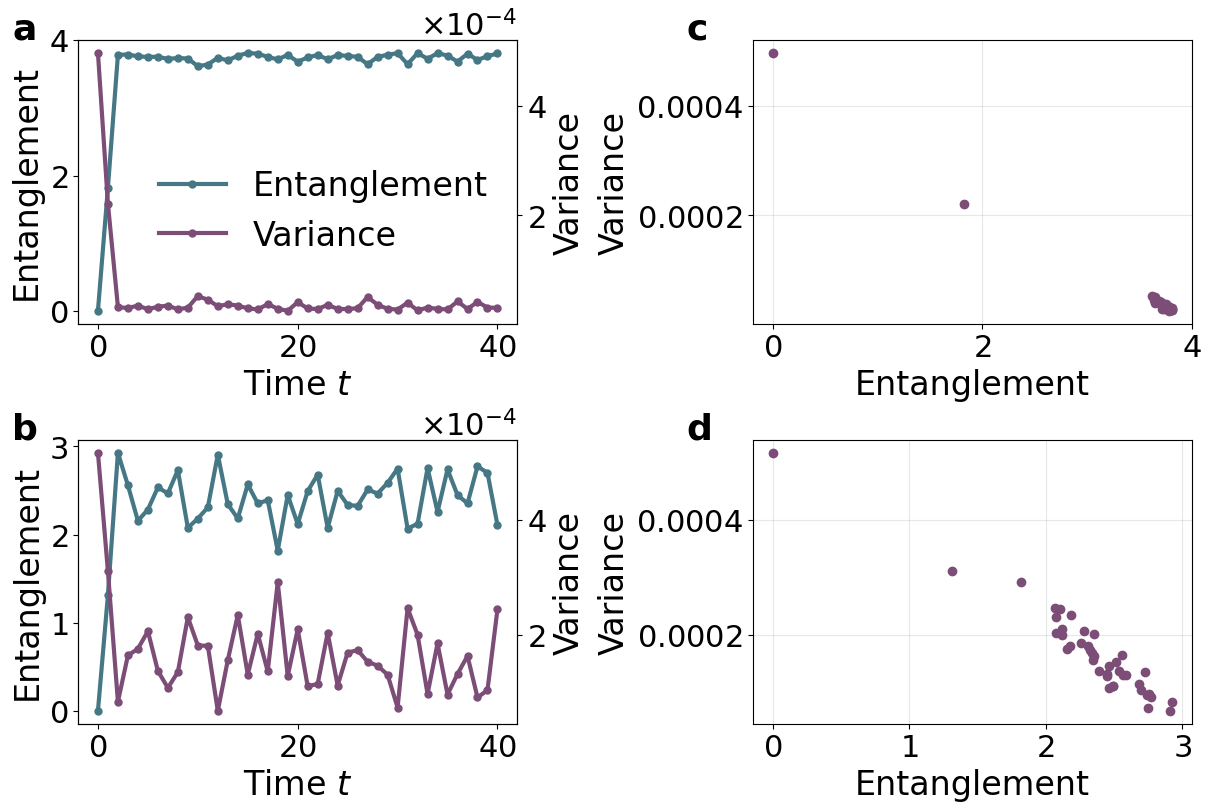

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

if "REPO_ROOT" in globals():
    OUTPUT_ROOT = REPO_ROOT / "reproduce" / "outputs" / "long_time_ent_variance"
else:
    OUTPUT_ROOT = Path("../outputs/long_time_ent_variance").resolve()
    if not OUTPUT_ROOT.exists():
        OUTPUT_ROOT = Path("reproduce/outputs/long_time_ent_variance").resolve()
FIGURE_DIR = OUTPUT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

typical_entropies = np.load(OUTPUT_ROOT / "typical" / "entropies.npy")
typical_variances = np.load(OUTPUT_ROOT / "typical" / "variances.npy")
atypical_entropies = np.load(OUTPUT_ROOT / "atypical" / "entropies.npy")
atypical_variances = np.load(OUTPUT_ROOT / "atypical" / "variances.npy")
STATE_DEPTH = len(typical_entropies) - 1

indices = np.arange(STATE_DEPTH + 1)
plot_cases = [
    (typical_entropies, typical_variances),
    (atypical_entropies, atypical_variances),
]

fs=24
ls=22
ts=26
plt.rcParams["axes.formatter.use_mathtext"] = True
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
panel_labels = [("a", "c"), ("b", "d")]
panel_label_kwargs = dict(
    fontsize=ts,
    fontweight="bold",
    color="black",
    va="top",
    ha="left",
)
for row, (entropies, variances) in enumerate(plot_cases):
    entropy_label, scatter_label = panel_labels[row]
    ax_entropy = axes[row, 0]
    ax_variance = ax_entropy.twinx()
    ax_variance.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax_variance.yaxis.get_offset_text().set_fontsize(ls)
    #ax_entropy.text(0.02, 0.96, entropy_label, transform=ax_entropy.transAxes, fontsize=ts, fontweight="bold", va="top", ha="left")
    ax_entropy.text(-0.15, 1.1, entropy_label, transform=ax_entropy.transAxes, **panel_label_kwargs)

    ax_entropy.plot(indices, entropies, "o-", color="#457785", linewidth=3, markersize=5, label="Entanglement")
    ax_variance.set_ylabel("Variance",fontsize=fs)
    ax_variance.plot(indices, variances, "o-", color="#7C4D77", linewidth=3, markersize=5, label="Variance")
    ax_entropy.set_xlabel(r"Time $t$",fontsize=fs)
    ax_entropy.set_ylabel("Entanglement",fontsize=fs)
    h1, l1 = ax_entropy.get_legend_handles_labels()
    h2, l2 = ax_variance.get_legend_handles_labels()
    if row == 0:
        ax_entropy.legend(h1 + h2, l1 + l2, loc="upper right", bbox_to_anchor=(1, .65), framealpha=0, fontsize=fs)
    #ax_entropy.legend(h1 + h2, l1 + l2, loc="best", framealpha=0)

    ax_entropy.tick_params(axis="both", labelsize=ls)
    ax_variance.tick_params(axis="y", labelsize=ls)
    

    ax_scatter = axes[row, 1]
    ax_scatter.text(-0.15, 1.1, scatter_label, transform=ax_scatter.transAxes, **panel_label_kwargs)
    #ax_scatter.text(0.02, 0.96, scatter_label, transform=ax_scatter.transAxes, fontsize=ts, fontweight="bold", va="top", ha="left")
    ax_scatter.plot(entropies, variances, "o", color="#7C4D77", markersize=6)
    ax_scatter.set_xlabel("Entanglement",fontsize=fs)
    ax_scatter.set_ylabel("Variance",fontsize=fs)
    ax_scatter.tick_params(axis="both", labelsize=ls)
    ax_scatter.grid(alpha=0.3)
    ax_scatter.yaxis.get_offset_text().set_fontsize(ls)

figure_path = FIGURE_DIR / "long_time_entanglement_variance.pdf"
plt.savefig(figure_path, bbox_inches="tight", pad_inches=0.1, dpi=200, transparent=True)
figure_path
